In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import scorecardpy as sc
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
master_df =pd.read_csv("../Dataset/processed/preliminary_dev_sample.csv")
print(master_df.shape)
print(master_df.SK_ID_CURR.nunique())
print(master_df.TARGET.value_counts(normalize=True))

(291643, 233)
291643
TARGET
0    0.969908
1    0.030092
Name: proportion, dtype: float64


### Target Distribution

TARGET = 1 → Customer reached 60+ DPD ever in entire observation window

TARGET = 0 → Customer remained below 60+ DPD in entire observation window

In [3]:
df = master_df.drop(
    columns=['SK_ID_CURR']
)
df.head(2)

,credit_income_ratio,annuity_income_ratio,goods_income_ratio,credit_goods_ratio,age_years,count_family_members,per_capita_income,children_ratio,employment_years,employment_age_ratio,registration_years,id_publish_years,owns_house,owns_car,own_car_age,ext_min,ext_mean,contact_count,document_count,social_default_cnt,social_risk_ratio,total_credit_enquiries,enquiry_L1M,high_credit_hunger_flag,total_tradelines,total_active_tradelines,total_closed_tradelines,total_credit_exposure,total_debt,total_overdue,max_overdue,avg_credit_overdue_days,max_credit_overdue_days,credit_prolongation_count,active_pct_tradelines,debt_to_utilization_ratio,avg_debt_per_tradeline,ever_delinquent_flag,avg_credit_age_years,num_accounts_AL,num_accounts_BL,num_accounts_CC,num_accounts_HL,num_accounts_INV,num_accounts_OTH,num_accounts_PL,total_exposure_AL,total_exposure_BL,total_exposure_CC,total_exposure_HL,total_exposure_INV,total_exposure_OTH,total_exposure_PL,total_debt_AL,total_debt_BL,total_debt_CC,total_debt_HL,total_debt_INV,total_debt_OTH,total_debt_PL,total_overdue_AL,total_overdue_BL,total_overdue_CC,total_overdue_HL,total_overdue_INV,total_overdue_OTH,total_overdue_PL,utilization_AL,utilization_BL,utilization_CC,utilization_HL,utilization_INV,utilization_OTH,utilization_PL,active_al,active_bl,active_cc,active_hl,active_inv,active_oth,active_pl,PL_max_dpd_l1m,PL_max_dpd_l3m,PL_max_dpd_l6m,PL_max_dpd_l12m,PL_cnt_30dpd_l1m,PL_cnt_60dpd_l1m,PL_cnt_90dpd_l1m,PL_cnt_30dpd_l3m,PL_cnt_60dpd_l3m,PL_cnt_90dpd_l3m,PL_cnt_30dpd_l6m,PL_cnt_60dpd_l6m,PL_cnt_90dpd_l6m,PL_cnt_30dpd_l12m,PL_cnt_60dpd_l12m,PL_cnt_90dpd_l12m,CC_max_dpd_l1m,CC_max_dpd_l3m,CC_max_dpd_l6m,CC_max_dpd_l12m,CC_cnt_30dpd_l1m,CC_cnt_60dpd_l1m,CC_cnt_90dpd_l1m,CC_cnt_30dpd_l3m,CC_cnt_60dpd_l3m,CC_cnt_90dpd_l3m,CC_cnt_30dpd_l6m,CC_cnt_60dpd_l6m,CC_cnt_90dpd_l6m,CC_cnt_30dpd_l12m,CC_cnt_60dpd_l12m,CC_cnt_90dpd_l12m,HL_max_dpd_l1m,HL_max_dpd_l3m,HL_max_dpd_l6m,HL_max_dpd_l12m,HL_cnt_30dpd_l1m,HL_cnt_60dpd_l1m,HL_cnt_90dpd_l1m,HL_cnt_30dpd_l3m,HL_cnt_60dpd_l3m,HL_cnt_90dpd_l3m,HL_cnt_30dpd_l6m,HL_cnt_60dpd_l6m,HL_cnt_90dpd_l6m,HL_cnt_30dpd_l12m,HL_cnt_60dpd_l12m,HL_cnt_90dpd_l12m,AL_max_dpd_l1m,AL_max_dpd_l3m,AL_max_dpd_l6m,AL_max_dpd_l12m,AL_cnt_30dpd_l1m,AL_cnt_60dpd_l1m,AL_cnt_90dpd_l1m,AL_cnt_30dpd_l3m,AL_cnt_60dpd_l3m,AL_cnt_90dpd_l3m,AL_cnt_30dpd_l6m,AL_cnt_60dpd_l6m,AL_cnt_90dpd_l6m,AL_cnt_30dpd_l12m,AL_cnt_60dpd_l12m,AL_cnt_90dpd_l12m,BL_max_dpd_l1m,BL_max_dpd_l3m,BL_max_dpd_l6m,BL_max_dpd_l12m,BL_cnt_30dpd_l1m,BL_cnt_60dpd_l1m,BL_cnt_90dpd_l1m,BL_cnt_30dpd_l3m,BL_cnt_60dpd_l3m,BL_cnt_90dpd_l3m,BL_cnt_30dpd_l6m,BL_cnt_60dpd_l6m,BL_cnt_90dpd_l6m,BL_cnt_30dpd_l12m,BL_cnt_60dpd_l12m,BL_cnt_90dpd_l12m,OTH_max_dpd_l1m,OTH_max_dpd_l3m,OTH_max_dpd_l6m,OTH_max_dpd_l12m,OTH_cnt_30dpd_l1m,OTH_cnt_60dpd_l1m,OTH_cnt_90dpd_l1m,OTH_cnt_30dpd_l3m,OTH_cnt_60dpd_l3m,OTH_cnt_90dpd_l3m,OTH_cnt_30dpd_l6m,OTH_cnt_60dpd_l6m,OTH_cnt_90dpd_l6m,OTH_cnt_30dpd_l12m,OTH_cnt_60dpd_l12m,OTH_cnt_90dpd_l12m,INV_max_dpd_l1m,INV_max_dpd_l3m,INV_max_dpd_l6m,INV_max_dpd_l12m,INV_cnt_30dpd_l1m,INV_cnt_60dpd_l1m,INV_cnt_90dpd_l1m,INV_cnt_30dpd_l3m,INV_cnt_60dpd_l3m,INV_cnt_90dpd_l3m,INV_cnt_30dpd_l6m,INV_cnt_60dpd_l6m,INV_cnt_90dpd_l6m,INV_cnt_30dpd_l12m,INV_cnt_60dpd_l12m,INV_cnt_90dpd_l12m,max_dpd_l1m,max_dpd_l3m,max_dpd_l6m,max_dpd_l12m,total_30dpd_l1m,total_60dpd_l1m,total_90dpd_l1m,total_30dpd_l3m,total_60dpd_l3m,total_90dpd_l3m,total_30dpd_l6m,total_60dpd_l6m,total_90dpd_l6m,total_30dpd_l12m,total_60dpd_l12m,total_90dpd_l12m,num_prev_apps,num_approved,num_refused,num_cancelled,approval_rate,rejection_rate,avg_application_amt,max_application_amt,avg_credit_amt,max_credit_amt,avg_credit_grant_ratio,min_credit_grant_ratio,avg_prev_term,max_prev_term,days_since_last_application,insurance_rate,on_us_max_dpd,on_us_avg_dpd,on_us_cnt_30dpd,on_us_cnt_60dpd,on_us_cnt_90dpd,avg_instalment_remaining,TARGET
0,2.007889,0.121978,1.733333,1.158397,25.920548,1.0,202500.0,0.0,1.745205,0.067329,9.994521,5.808219,1,0,NaN,0.083037,0.161787

### Missing Data Treatment

In [4]:
missing_pct = (
    df
    .isnull()
    .mean()
    .sort_values(ascending=False)
    *100
)

missing_pct.head(50)

own_car_age          66.16034
HL_max_dpd_l12m      14.27773
AL_cnt_30dpd_l1m     14.27773
AL_cnt_90dpd_l1m     14.27773
AL_cnt_30dpd_l3m     14.27773
AL_cnt_60dpd_l3m     14.27773
AL_cnt_90dpd_l3m     14.27773
AL_cnt_30dpd_l6m     14.27773
AL_cnt_60dpd_l6m     14.27773
AL_cnt_90dpd_l6m     14.27773
AL_cnt_30dpd_l12m    14.27773
AL_cnt_60dpd_l12m    14.27773
AL_cnt_90dpd_l12m    14.27773
BL_max_dpd_l1m       14.27773
BL_max_dpd_l3m       14.27773
BL_max_dpd_l6m       14.27773
BL_max_dpd_l12m      14.27773
BL_cnt_30dpd_l1m     14.27773
BL_cnt_60dpd_l1m     14.27773
BL_cnt_90dpd_l1m     14.27773
BL_cnt_30dpd_l3m     14.27773
BL_cnt_60dpd_l3m     14.27773
BL_cnt_90dpd_l3m     14.27773
BL_cnt_30dpd_l6m     14.27773
BL_cnt_60dpd_l6m     14.27773
AL_cnt_60dpd_l1m     14.27773
AL_max_dpd_l12m      14.27773
BL_cnt_30dpd_l12m    14.27773
HL_cnt_90dpd_l1m     14.27773
CC_cnt_60dpd_l6m     14.27773
CC_cnt_90dpd_l6m     14.27773
CC_cnt_30dpd_l12m    14.27773
CC_cnt_60dpd_l12m    14.27773
CC_cnt_90d

In [5]:
for col in [
    'own_car_age'
]:

    df[f'{col}_missing'] = (
        df[col].isnull()
    ).astype(int)

In [6]:
df.head(2)

,credit_income_ratio,annuity_income_ratio,goods_income_ratio,credit_goods_ratio,age_years,count_family_members,per_capita_income,children_ratio,employment_years,employment_age_ratio,registration_years,id_publish_years,owns_house,owns_car,own_car_age,ext_min,ext_mean,contact_count,document_count,social_default_cnt,social_risk_ratio,total_credit_enquiries,enquiry_L1M,high_credit_hunger_flag,total_tradelines,total_active_tradelines,total_closed_tradelines,total_credit_exposure,total_debt,total_overdue,max_overdue,avg_credit_overdue_days,max_credit_overdue_days,credit_prolongation_count,active_pct_tradelines,debt_to_utilization_ratio,avg_debt_per_tradeline,ever_delinquent_flag,avg_credit_age_years,num_accounts_AL,num_accounts_BL,num_accounts_CC,num_accounts_HL,num_accounts_INV,num_accounts_OTH,num_accounts_PL,total_exposure_AL,total_exposure_BL,total_exposure_CC,total_exposure_HL,total_exposure_INV,total_exposure_OTH,total_exposure_PL,total_debt_AL,total_debt_BL,total_debt_CC,total_debt_HL,total_debt_INV,total_debt_OTH,total_debt_PL,total_overdue_AL,total_overdue_BL,total_overdue_CC,total_overdue_HL,total_overdue_INV,total_overdue_OTH,total_overdue_PL,utilization_AL,utilization_BL,utilization_CC,utilization_HL,utilization_INV,utilization_OTH,utilization_PL,active_al,active_bl,active_cc,active_hl,active_inv,active_oth,active_pl,PL_max_dpd_l1m,PL_max_dpd_l3m,PL_max_dpd_l6m,PL_max_dpd_l12m,PL_cnt_30dpd_l1m,PL_cnt_60dpd_l1m,PL_cnt_90dpd_l1m,PL_cnt_30dpd_l3m,PL_cnt_60dpd_l3m,PL_cnt_90dpd_l3m,PL_cnt_30dpd_l6m,PL_cnt_60dpd_l6m,PL_cnt_90dpd_l6m,PL_cnt_30dpd_l12m,PL_cnt_60dpd_l12m,PL_cnt_90dpd_l12m,CC_max_dpd_l1m,CC_max_dpd_l3m,CC_max_dpd_l6m,CC_max_dpd_l12m,CC_cnt_30dpd_l1m,CC_cnt_60dpd_l1m,CC_cnt_90dpd_l1m,CC_cnt_30dpd_l3m,CC_cnt_60dpd_l3m,CC_cnt_90dpd_l3m,CC_cnt_30dpd_l6m,CC_cnt_60dpd_l6m,CC_cnt_90dpd_l6m,CC_cnt_30dpd_l12m,CC_cnt_60dpd_l12m,CC_cnt_90dpd_l12m,HL_max_dpd_l1m,HL_max_dpd_l3m,HL_max_dpd_l6m,HL_max_dpd_l12m,HL_cnt_30dpd_l1m,HL_cnt_60dpd_l1m,HL_cnt_90dpd_l1m,HL_cnt_30dpd_l3m,HL_cnt_60dpd_l3m,HL_cnt_90dpd_l3m,HL_cnt_30dpd_l6m,HL_cnt_60dpd_l6m,HL_cnt_90dpd_l6m,HL_cnt_30dpd_l12m,HL_cnt_60dpd_l12m,HL_cnt_90dpd_l12m,AL_max_dpd_l1m,AL_max_dpd_l3m,AL_max_dpd_l6m,AL_max_dpd_l12m,AL_cnt_30dpd_l1m,AL_cnt_60dpd_l1m,AL_cnt_90dpd_l1m,AL_cnt_30dpd_l3m,AL_cnt_60dpd_l3m,AL_cnt_90dpd_l3m,AL_cnt_30dpd_l6m,AL_cnt_60dpd_l6m,AL_cnt_90dpd_l6m,AL_cnt_30dpd_l12m,AL_cnt_60dpd_l12m,AL_cnt_90dpd_l12m,BL_max_dpd_l1m,BL_max_dpd_l3m,BL_max_dpd_l6m,BL_max_dpd_l12m,BL_cnt_30dpd_l1m,BL_cnt_60dpd_l1m,BL_cnt_90dpd_l1m,BL_cnt_30dpd_l3m,BL_cnt_60dpd_l3m,BL_cnt_90dpd_l3m,BL_cnt_30dpd_l6m,BL_cnt_60dpd_l6m,BL_cnt_90dpd_l6m,BL_cnt_30dpd_l12m,BL_cnt_60dpd_l12m,BL_cnt_90dpd_l12m,OTH_max_dpd_l1m,OTH_max_dpd_l3m,OTH_max_dpd_l6m,OTH_max_dpd_l12m,OTH_cnt_30dpd_l1m,OTH_cnt_60dpd_l1m,OTH_cnt_90dpd_l1m,OTH_cnt_30dpd_l3m,OTH_cnt_60dpd_l3m,OTH_cnt_90dpd_l3m,OTH_cnt_30dpd_l6m,OTH_cnt_60dpd_l6m,OTH_cnt_90dpd_l6m,OTH_cnt_30dpd_l12m,OTH_cnt_60dpd_l12m,OTH_cnt_90dpd_l12m,INV_max_dpd_l1m,INV_max_dpd_l3m,INV_max_dpd_l6m,INV_max_dpd_l12m,INV_cnt_30dpd_l1m,INV_cnt_60dpd_l1m,INV_cnt_90dpd_l1m,INV_cnt_30dpd_l3m,INV_cnt_60dpd_l3m,INV_cnt_90dpd_l3m,INV_cnt_30dpd_l6m,INV_cnt_60dpd_l6m,INV_cnt_90dpd_l6m,INV_cnt_30dpd_l12m,INV_cnt_60dpd_l12m,INV_cnt_90dpd_l12m,max_dpd_l1m,max_dpd_l3m,max_dpd_l6m,max_dpd_l12m,total_30dpd_l1m,total_60dpd_l1m,total_90dpd_l1m,total_30dpd_l3m,total_60dpd_l3m,total_90dpd_l3m,total_30dpd_l6m,total_60dpd_l6m,total_90dpd_l6m,total_30dpd_l12m,total_60dpd_l12m,total_90dpd_l12m,num_prev_apps,num_approved,num_refused,num_cancelled,approval_rate,rejection_rate,avg_application_amt,max_application_amt,avg_credit_amt,max_credit_amt,avg_credit_grant_ratio,min_credit_grant_ratio,avg_prev_term,max_prev_term,days_since_last_application,insurance_rate,on_us_max_dpd,on_us_avg_dpd,on_us_cnt_30dpd,on_us_cnt_60dpd,on_us_cnt_90dpd,avg_instalment_remaining,TARGET,own_car_age_missing
0,2.007889,0.121978,1.733333,1.158397,25.920548,1.0,202500.0,0.0,1.745205,0.067329,9.994521,5.808219,1,0,N

In [7]:
## Imputing Numerical Columns with Median except Target
num_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

num_cols.remove('TARGET')

for col in num_cols:

    df[col] = df[col].fillna(
        df[col].median()
    )
df.isnull().sum()    

credit_income_ratio            0
annuity_income_ratio           0
goods_income_ratio             0
credit_goods_ratio             0
age_years                      0
count_family_members           0
per_capita_income              0
children_ratio                 0
employment_years               0
employment_age_ratio           0
registration_years             0
id_publish_years               0
owns_house                     0
owns_car                       0
own_car_age                    0
ext_min                        0
ext_mean                       0
contact_count                  0
document_count                 0
social_default_cnt             0
social_risk_ratio              0
total_credit_enquiries         0
enquiry_L1M                    0
high_credit_hunger_flag        0
total_tradelines               0
total_active_tradelines        0
total_closed_tradelines        0
total_credit_exposure          0
total_debt                     0
total_overdue                  0
max_overdu

### Outlier Treatment

In [8]:
def cap_outliers(df,col):

    p01 = df[col].quantile(.01)

    p99 = df[col].quantile(.99)

    df[col] = np.clip(
        df[col],
        p01,
        p99
    )

    return df

for col in num_cols:

    df = cap_outliers(
        df,
        col
    )

df.describe()

,credit_income_ratio,annuity_income_ratio,goods_income_ratio,credit_goods_ratio,age_years,count_family_members,per_capita_income,children_ratio,employment_years,employment_age_ratio,registration_years,id_publish_years,owns_house,owns_car,own_car_age,ext_min,ext_mean,contact_count,document_count,social_default_cnt,social_risk_ratio,total_credit_enquiries,enquiry_L1M,high_credit_hunger_flag,total_tradelines,total_active_tradelines,total_closed_tradelines,total_credit_exposure,total_debt,total_overdue,max_overdue,avg_credit_overdue_days,max_credit_overdue_days,credit_prolongation_count,active_pct_tradelines,debt_to_utilization_ratio,avg_debt_per_tradeline,ever_delinquent_flag,avg_credit_age_years,num_accounts_AL,num_accounts_BL,num_accounts_CC,num_accounts_HL,num_accounts_INV,num_accounts_OTH,num_accounts_PL,total_exposure_AL,total_exposure_BL,total_exposure_CC,total_exposure_HL,total_exposure_INV,total_exposure_OTH,total_exposure_PL,total_debt_AL,total_debt_BL,total_debt_CC,total_debt_HL,total_debt_INV,total_debt_OTH,total_debt_PL,total_overdue_AL,total_overdue_BL,total_overdue_CC,total_overdue_HL,total_overdue_INV,total_overdue_OTH,total_overdue_PL,utilization_AL,utilization_BL,utilization_CC,utilization_HL,utilization_INV,utilization_OTH,utilization_PL,active_al,active_bl,active_cc,active_hl,active_inv,active_oth,active_pl,PL_max_dpd_l1m,PL_max_dpd_l3m,PL_max_dpd_l6m,PL_max_dpd_l12m,PL_cnt_30dpd_l1m,PL_cnt_60dpd_l1m,PL_cnt_90dpd_l1m,PL_cnt_30dpd_l3m,PL_cnt_60dpd_l3m,PL_cnt_90dpd_l3m,PL_cnt_30dpd_l6m,PL_cnt_60dpd_l6m,PL_cnt_90dpd_l6m,PL_cnt_30dpd_l12m,PL_cnt_60dpd_l12m,PL_cnt_90dpd_l12m,CC_max_dpd_l1m,CC_max_dpd_l3m,CC_max_dpd_l6m,CC_max_dpd_l12m,CC_cnt_30dpd_l1m,CC_cnt_60dpd_l1m,CC_cnt_90dpd_l1m,CC_cnt_30dpd_l3m,CC_cnt_60dpd_l3m,CC_cnt_90dpd_l3m,CC_cnt_30dpd_l6m,CC_cnt_60dpd_l6m,CC_cnt_90dpd_l6m,CC_cnt_30dpd_l12m,CC_cnt_60dpd_l12m,CC_cnt_90dpd_l12m,HL_max_dpd_l1m,HL_max_dpd_l3m,HL_max_dpd_l6m,HL_max_dpd_l12m,HL_cnt_30dpd_l1m,HL_cnt_60dpd_l1m,HL_cnt_90dpd_l1m,HL_cnt_30dpd_l3m,HL_cnt_60dpd_l3m,HL_cnt_90dpd_l3m,HL_cnt_30dpd_l6m,HL_cnt_60dpd_l6m,HL_cnt_90dpd_l6m,HL_cnt_30dpd_l12m,HL_cnt_60dpd_l12m,HL_cnt_90dpd_l12m,AL_max_dpd_l1m,AL_max_dpd_l3m,AL_max_dpd_l6m,AL_max_dpd_l12m,AL_cnt_30dpd_l1m,AL_cnt_60dpd_l1m,AL_cnt_90dpd_l1m,AL_cnt_30dpd_l3m,AL_cnt_60dpd_l3m,AL_cnt_90dpd_l3m,AL_cnt_30dpd_l6m,AL_cnt_60dpd_l6m,AL_cnt_90dpd_l6m,AL_cnt_30dpd_l12m,AL_cnt_60dpd_l12m,AL_cnt_90dpd_l12m,BL_max_dpd_l1m,BL_max_dpd_l3m,BL_max_dpd_l6m,BL_max_dpd_l12m,BL_cnt_30dpd_l1m,BL_cnt_60dpd_l1m,BL_cnt_90dpd_l1m,BL_cnt_30dpd_l3m,BL_cnt_60dpd_l3m,BL_cnt_90dpd_l3m,BL_cnt_30dpd_l6m,BL_cnt_60dpd_l6m,BL_cnt_90dpd_l6m,BL_cnt_30dpd_l12m,BL_cnt_60dpd_l12m,BL_cnt_90dpd_l12m,OTH_max_dpd_l1m,OTH_max_dpd_l3m,OTH_max_dpd_l6m,OTH_max_dpd_l12m,OTH_cnt_30dpd_l1m,OTH_cnt_60dpd_l1m,OTH_cnt_90dpd_l1m,OTH_cnt_30dpd_l3m,OTH_cnt_60dpd_l3m,OTH_cnt_90dpd_l3m,OTH_cnt_30dpd_l6m,OTH_cnt_60dpd_l6m,OTH_cnt_90dpd_l6m,OTH_cnt_30dpd_l12m,OTH_cnt_60dpd_l12m,OTH_cnt_90dpd_l12m,INV_max_dpd_l1m,INV_max_dpd_l3m,INV_max_dpd_l6m,INV_max_dpd_l12m,INV_cnt_30dpd_l1m,INV_cnt_60dpd_l1m,INV_cnt_90dpd_l1m,INV_cnt_30dpd_l3m,INV_cnt_60dpd_l3m,INV_cnt_90dpd_l3m,INV_cnt_30dpd_l6m,INV_cnt_60dpd_l6m,INV_cnt_90dpd_l6m,INV_cnt_30dpd_l12m,INV_cnt_60dpd_l12m,INV_cnt_90dpd_l12m,max_dpd_l1m,max_dpd_l3m,max_dpd_l6m,max_dpd_l12m,total_30dpd_l1m,total_60dpd_l1m,total_90dpd_l1m,total_30dpd_l3m,total_60dpd_l3m,total_90dpd_l3m,total_30dpd_l6m,total_60dpd_l6m,total_90dpd_l6m,total_30dpd_l12m,total_60dpd_l12m,total_90dpd_l12m,num_prev_apps,num_approved,num_refused,num_cancelled,approval_rate,rejection_rate,avg_application_amt,max_application_amt,avg_credit_amt,max_credit_amt,avg_credit_grant_ratio,min_credit_grant_ratio,avg_prev_term,max_prev_term,days_since_last_application,insurance_rate,on_us_max_dpd,on_us_avg_dpd,on_us_cnt_30dpd,on_us_cnt_60dpd,on_us_cnt_90dpd,avg_instalment_remaining,TARGET,own_car_age_missing
count,291643.000000,291643.000000,291643.000000,291643.000000,291643.000000,291643.000000,291643.000000,29

### Train Test Split Before WoE

In [9]:
X = df.drop(
    columns=['TARGET']
)

y = df['TARGET']

X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,

    test_size=.30,

    stratify=y,

    random_state=42

)

train_df = pd.concat(
    [X_train,y_train],
    axis=1
)

test_df = pd.concat(
    [X_test,y_test],
    axis=1
)

print(train_df.shape)

print(test_df.shape)

(204150, 233)
(87493, 233)


### Feature Selection
#### Step 1: IV Table

In [10]:
train_df.shape

(204150, 233)

In [11]:
[c for c in train_df.columns if 'install' in c.lower() or 'instal' in c.lower()]

['avg_instalment_remaining']

In [12]:
bins = sc.woebin( train_df, y='TARGET' ) 
bins.keys()

[INFO] creating woe binning ...
Binning on 204150 rows and 105 columns in 00:01:48


dict_keys(['owns_car', 'total_debt', 'num_refused', 'max_overdue', 'total_debt_CC', 'max_dpd_l6m', 'utilization_PL', 'max_credit_overdue_days', 'avg_credit_age_years', 'active_pl', 'registration_years', 'credit_prolongation_count', 'PL_cnt_30dpd_l12m', 'approval_rate', 'total_30dpd_l1m', 'PL_max_dpd_l3m', 'total_debt_HL', 'on_us_cnt_60dpd', 'active_cc', 'num_cancelled', 'credit_goods_ratio', 'max_dpd_l12m', 'max_credit_amt', 'num_prev_apps', 'PL_cnt_30dpd_l1m', 'count_family_members', 'avg_application_amt', 'total_active_tradelines', 'total_exposure_HL', 'total_debt_AL', 'total_exposure_CC', 'employment_years', 'document_count', 'utilization_AL', 'max_prev_term', 'active_al', 'PL_max_dpd_l1m', 'CC_max_dpd_l1m', 'total_exposure_PL', 'employment_age_ratio', 'active_pct_tradelines', 'total_credit_exposure', 'age_years', 'owns_house', 'enquiry_L1M', 'annuity_income_ratio', 'total_credit_enquiries', 'CC_cnt_30dpd_l12m', 'avg_debt_per_tradeline', 'goods_income_ratio', 'total_closed_tradeline

In [13]:
constant_cols = [
    col
    for col in train_df.columns
    if train_df[col].nunique(dropna=False) <= 1
]

print(len(constant_cols))
print(constant_cols[:10])

128
['num_accounts_BL', 'num_accounts_INV', 'num_accounts_OTH', 'total_exposure_BL', 'total_exposure_INV', 'total_exposure_OTH', 'total_debt_BL', 'total_debt_INV', 'total_debt_OTH', 'total_overdue_AL']


In [14]:
128+105

233

In [15]:
from tqdm.auto import tqdm

import pandas as pd

iv_list = []

for var in tqdm(
    bins.keys(),
    total=len(bins),
    desc="Calculating IV"
):

    try:
        iv_list.append({
            "variable": var,
            "info_value": bins[var]["total_iv"].iloc[0]
        })

    except Exception:
        continue

iv_df = (
    pd.DataFrame(iv_list)
    .sort_values(
        "info_value",
        ascending=False
    )
    .reset_index(drop=True)
)

iv_df.head(20)

Calculating IV: 100%|██████████| 104/104 [00:00<00:00, 10892.39it/s]


,variable,info_value
0,on_us_max_dpd,2.104318
1,on_us_avg_dpd,1.930496
2,avg_instalment_remaining,0.264909
3,num_approved,0.146958
4,min_credit_grant_ratio,0.144764
5,num_prev_apps,0.116316
6,insurance_rate,0.087500
7,avg_credit_grant_ratio,0.072336
8,age_years,0.060605
9,rejection_rate,0.052979


In [16]:
iv_df['iv_bucket'] = pd.cut(
    iv_df['info_value'],
    bins=[-np.inf,0.02,0.1,0.3,0.5,np.inf],
    labels=[
        'Weak',
        'Medium',
        'Strong',
        'Very Strong',
        'Suspicious'
    ]
)

iv_df['iv_bucket'].value_counts()

iv_bucket
Weak           86
Medium         12
Strong          4
Suspicious      2
Very Strong     0
Name: count, dtype: int64

In [17]:
iv_df[iv_df['info_value'] > 0.5]

,variable,info_value,iv_bucket
0,on_us_max_dpd,2.104318,Suspicious
1,on_us_avg_dpd,1.930496,Suspicious


In [18]:
iv_df.to_csv(
    "../Reports/iv_summary.csv",
    index=False
)

In [19]:
iv_selected = (
    iv_df[
        iv_df['info_value'] >= 0.02
    ]['variable']
    .tolist()
)

len(iv_selected)

18

### Step 2: WOE Binning for IV Selected Features

In [20]:
iv_df[
        iv_df['info_value'] >= 0.02
    ]

,variable,info_value,iv_bucket
0,on_us_max_dpd,2.104318,Suspicious
1,on_us_avg_dpd,1.930496,Suspicious
2,avg_instalment_remaining,0.264909,Strong
3,num_approved,0.146958,Strong
4,min_credit_grant_ratio,0.144764,Strong
5,num_prev_apps,0.116316,Strong
6,insurance_rate,0.087500,Medium
7,avg_credit_grant_ratio,0.072336,Medium
8,age_years,0.060605,Medium
9,rejection_rate,0.052979,Medium


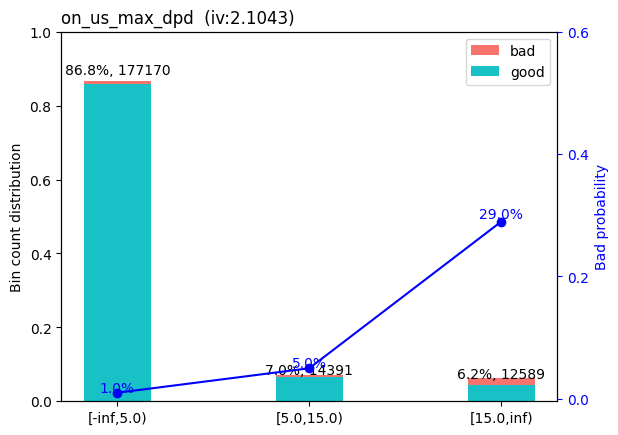

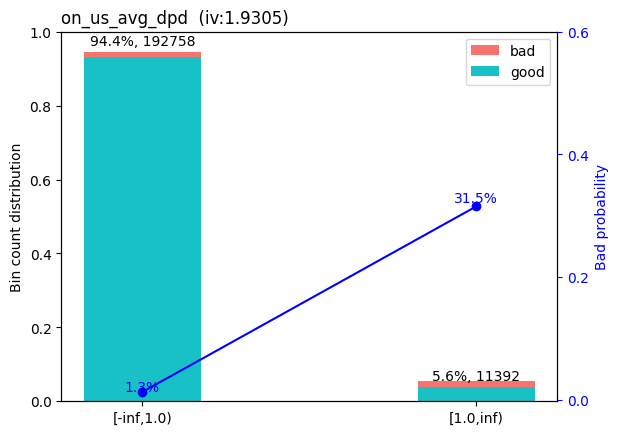

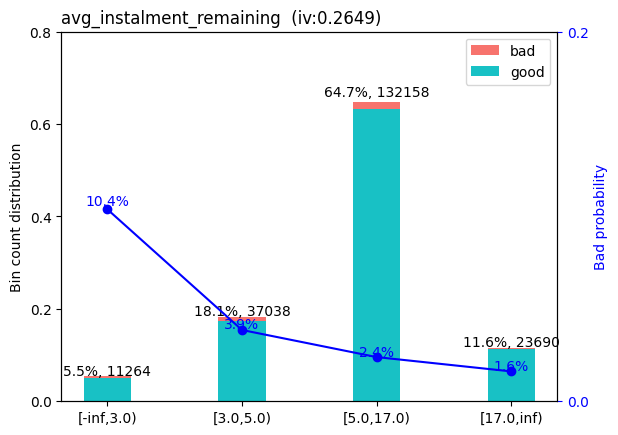

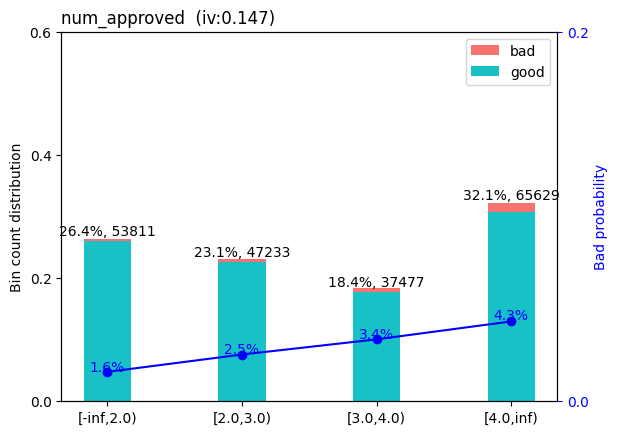

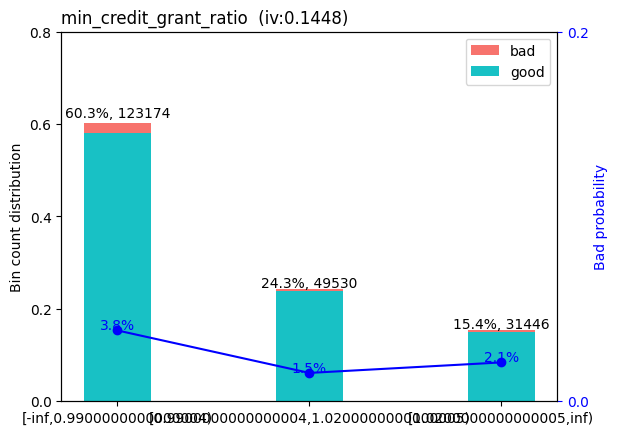

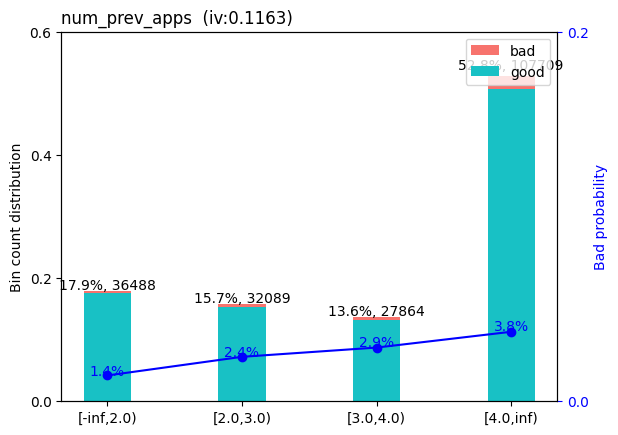

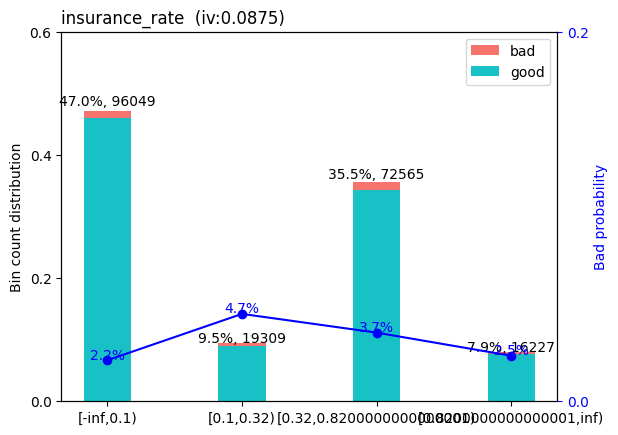

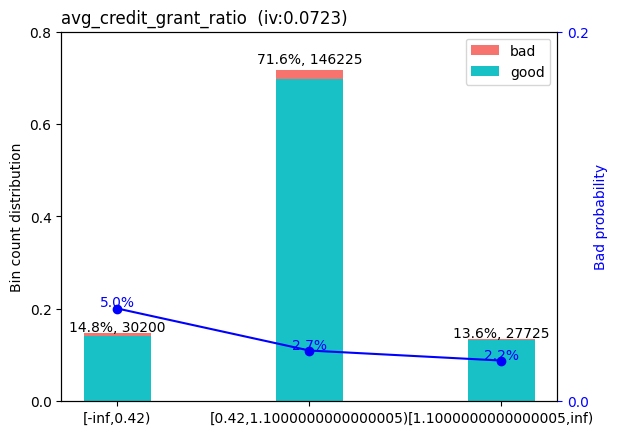

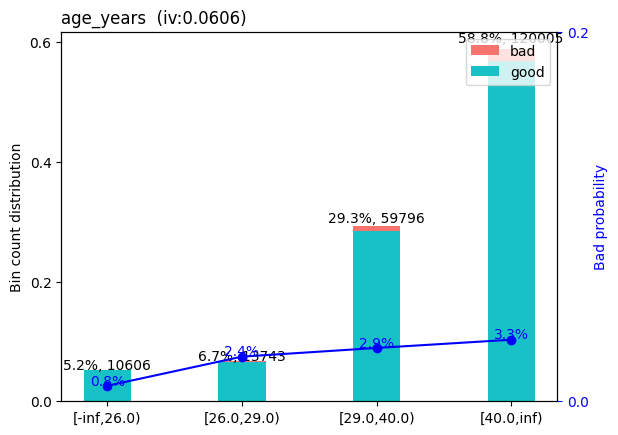

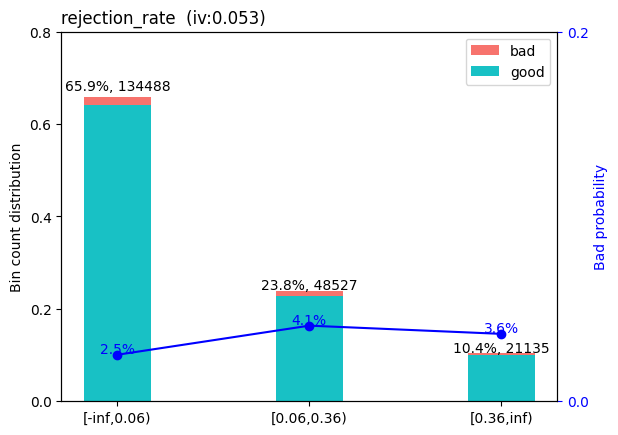

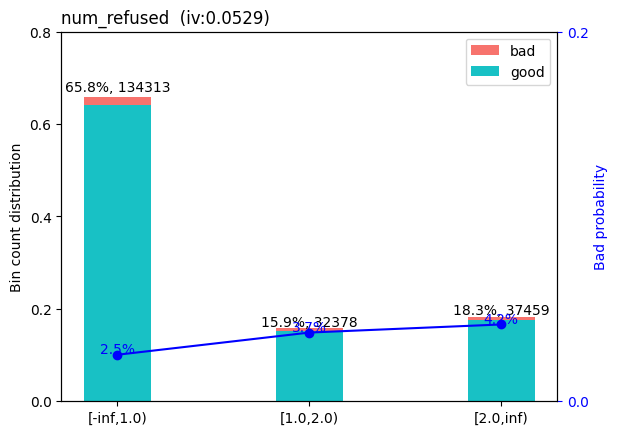

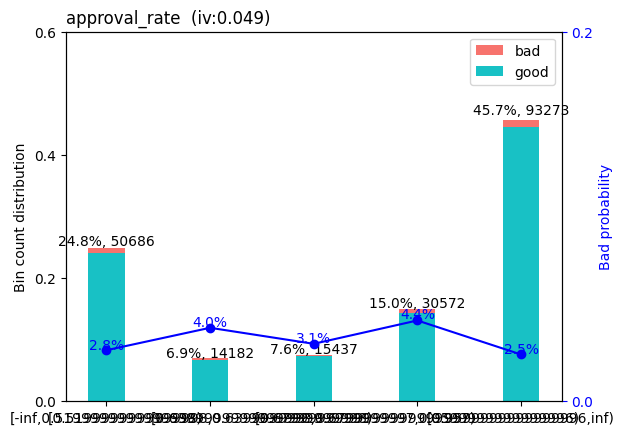

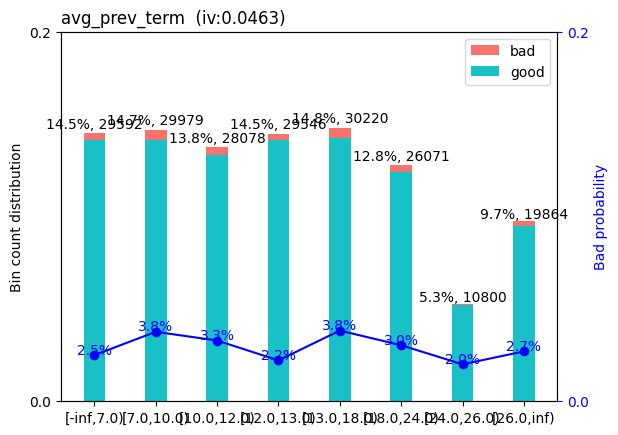

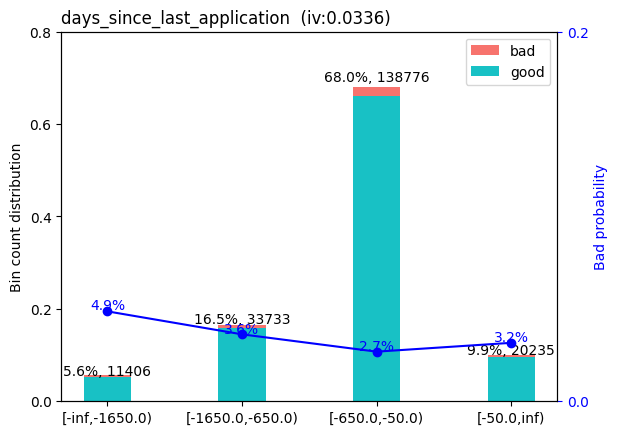

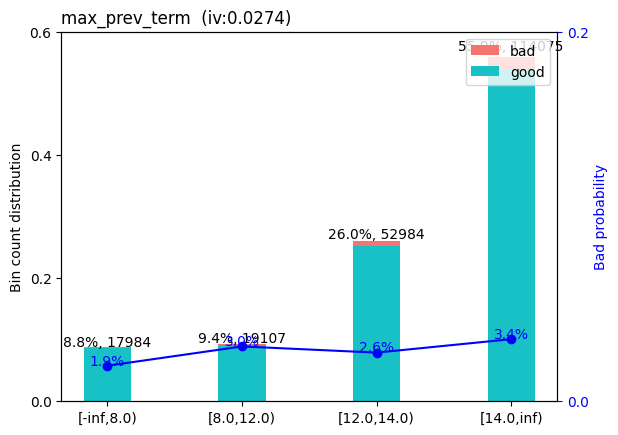

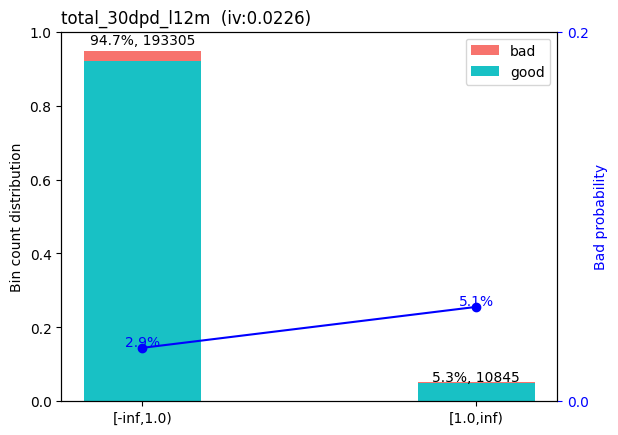

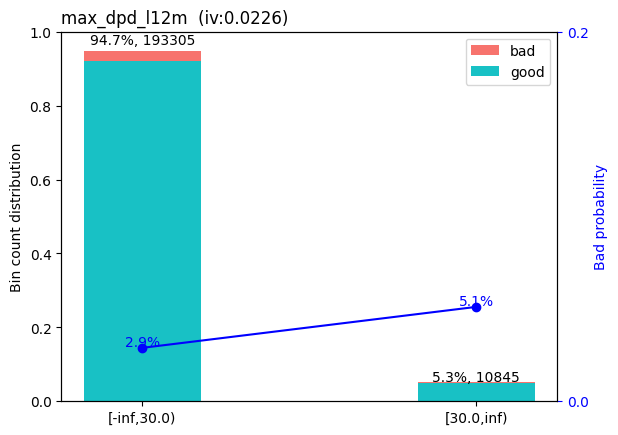

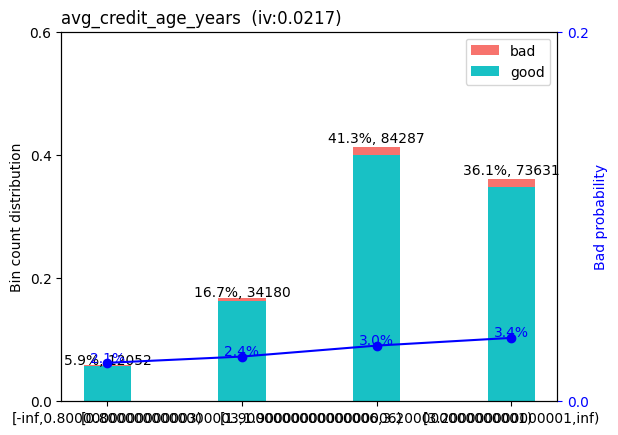

In [21]:
import os

os.makedirs("../Reports/woe_plots", exist_ok=True)

for var in iv_selected:
    
    try:
        plot_dict = sc.woebin_plot(bins[var])
        
        fig = list(plot_dict.values())[0]
        
        fig.savefig(
            f"../Reports/woe_plots/{var}.png",
            bbox_inches="tight"
        )
        
    except:
        pass

In [22]:
candidate_vars = [

    'avg_instalment_remaining',

    'num_approved',

    'num_prev_apps',

    'age_years',

    'avg_credit_grant_ratio',

    'num_refused',

    'max_dpd_l12m',

    'total_30dpd_l12m',

    'avg_credit_age_years'

]

### Final Candidate Variable Selection

Following Information Value (IV) screening, WOE trend assessment, and leakage review, a final set of candidate variables was selected for multicollinearity testing and logistic regression model development.

Variables exhibiting target leakage (`on_us_avg_dpd`, `on_us_max_dpd`) were removed, while variables with weak predictive power or non-monotonic risk behaviour were excluded during manual review.

The retained variables demonstrate meaningful discriminatory power, stable risk trends, and strong business interpretability.

| Variable                      | Business Interpretation                                                               |
| ----------------------------- | ------------------------------------------------------------------------------------- |
| **avg_installment_remaining** | Captures remaining repayment obligation and borrower repayment profile.               |
| **num_approved**              | Reflects historical credit exposure and borrowing intensity.                          |
| **num_prev_apps**             | Measures credit-seeking behaviour and potential credit hunger.                        |
| **age_years**                 | Represents borrower demographic and lifecycle risk characteristics.                   |
| **avg_credit_grant_ratio**    | Indicates historical lender willingness to grant requested credit.                    |
| **num_refused**               | Captures prior adverse lending decisions and creditworthiness concerns.               |
| **max_dpd_l12m**              | Measures the severity of historical delinquency behaviour observed in bureau records. |
| **total_30dpd_l12m**          | Captures early-stage repayment stress through recent delinquency occurrences.         |
| **avg_credit_age_years**      | Represents depth and maturity of the customer's credit history.                       |

### Variable Selection Methodology

The final candidate variables were retained based on the following criteria:

* Information Value (IV) ≥ 0.02
* Monotonic WOE and bad-rate trends
* Strong business relevance and interpretability
* No evidence of target leakage
* Suitability for logistic regression scorecard modeling

These variables will subsequently undergo Variance Inflation Factor (VIF) analysis to identify and remove multicollinearity prior to Probability of Default (PD) model development.


### VIF Criteria

##### Transforming train and test datasets using the WoE bins before VIF and multicollinearity checks

In [23]:
train_woe = sc.woebin_ply(train_df, bins)
test_woe = sc.woebin_ply(test_df, bins)

[INFO] converting into woe values ...
Woe transformating on 204150 rows and 104 columns in 00:02:44
[INFO] converting into woe values ...
Woe transformating on 87493 rows and 104 columns in 00:00:50


##### VIF Dataset Creation

In [24]:
woe_cols = set(train_woe.columns)

for var in candidate_vars:

    expected = f"{var}_woe"

    if expected not in woe_cols:
        print(f"Missing: {expected}")

In [25]:
'avg_instalment_remaining' in bins.keys()

True

In [26]:
woe_vars = [f"{col}_woe" for col in candidate_vars]

X_vif = train_woe[woe_vars].copy()

print(f"Variables entering VIF stage: {X_vif.shape[1]}")
X_vif.head()

Variables entering VIF stage: 9


,avg_instalment_remaining_woe,num_approved_woe,num_prev_apps_woe,age_years_woe,avg_credit_grant_ratio_woe,num_refused_woe,max_dpd_l12m_woe,total_30dpd_l12m_woe,avg_credit_age_years_woe
110658,-0.235912,0.375540,0.230856,0.104874,-0.094022,0.219054,-0.041141,-0.041141,0.001118
282603,-0.235912,0.111282,-0.035567,0.104874,-0.094022,-0.183214,-0.041141,-0.041141,0.135469
28614,-0.235912,0.111282,-0.035567,-0.043450,-0.094022,-0.183214,-0.041141,-0.041141,0.001118
130507,-0.235912,0.375540,0.230856,-0.043450,0.532725,-0.183214,-0.041141,-0.041141,0.135469
109881,-0.635485,-0.178332,-0.229943,-0.043450,-0.094022,-0.183214,-0.041141,-0.041141,0.135469


##### VIF calculation

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_df = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [
        variance_inflation_factor(
            X_vif.values,
            i
        )
        for i in range(X_vif.shape[1])
    ]
}).sort_values(
    'VIF',
    ascending=False
)

vif_df

,feature,VIF
6,max_dpd_l12m_woe,inf
7,total_30dpd_l12m_woe,inf
2,num_prev_apps_woe,3.773584
1,num_approved_woe,3.374711
5,num_refused_woe,1.363200
4,avg_credit_grant_ratio_woe,1.142173
8,avg_credit_age_years_woe,1.089410
3,age_years_woe,1.086823
0,avg_instalment_remaining_woe,1.028748


##### Final Dataset for Modelling

In [28]:
final_features = [

    'avg_instalment_remaining_woe',

    'num_approved_woe',

    'num_prev_apps_woe',

    'age_years_woe',

    'avg_credit_grant_ratio_woe',

    'num_refused_woe',

    'avg_credit_age_years_woe'

]

train_model = train_woe[
    final_features + ['TARGET']
].copy()

test_model = test_woe[
    final_features + ['TARGET']
].copy()

In [29]:
train_model.to_csv(
    "../Dataset/processed/train_model.csv",
    index=False
)

test_model.to_csv(
    "../Dataset/processed/test_model.csv",
    index=False
)

### Final Model Development Dataset

Following IV screening, monotonic trend assessment, leakage review, and multicollinearity analysis, a final set of seven predictor variables was selected for Probability of Default (PD) model development.

The final feature set captures borrower demographics, historical credit exposure, prior lending decisions, credit history maturity, and delinquency behaviour while maintaining strong interpretability and low multicollinearity.

#### Final Variables

* avg_instalment_remaining
* num_approved
* num_prev_apps
* age_years
* avg_credit_grant_ratio
* num_refused
* avg_credit_age_years

These variables will be used in Notebook 05 for logistic regression model development, coefficient sign assessment, model performance evaluation, score scaling, and scorecard generation.


In [34]:
import pickle

with open("../Models/woe_bins.pkl", "wb") as f:
    pickle.dump(bins, f)

In [35]:
final_features = [

    'avg_instalment_remaining_woe',

    'num_approved_woe',

    'num_prev_apps_woe',

    'age_years_woe',

    'avg_credit_grant_ratio_woe',

    'num_refused_woe',

    'avg_credit_age_years_woe'

]

with open("../Models/candidate_vars.pkl", "wb") as f:
    pickle.dump(final_features, f)

In [36]:
vif_df.to_csv(
    "../Reports/vif_summary.csv",
    index=False
)

In [1]:
import joblib

woe_bins = joblib.load("../Models/woe_bins.pkl")

print(type(woe_bins))
print(woe_bins.keys())

<class 'dict'>
dict_keys(['owns_car', 'total_debt', 'num_refused', 'max_overdue', 'total_debt_CC', 'max_dpd_l6m', 'utilization_PL', 'max_credit_overdue_days', 'avg_credit_age_years', 'active_pl', 'registration_years', 'credit_prolongation_count', 'PL_cnt_30dpd_l12m', 'approval_rate', 'total_30dpd_l1m', 'PL_max_dpd_l3m', 'total_debt_HL', 'on_us_cnt_60dpd', 'active_cc', 'num_cancelled', 'credit_goods_ratio', 'max_dpd_l12m', 'max_credit_amt', 'num_prev_apps', 'PL_cnt_30dpd_l1m', 'count_family_members', 'avg_application_amt', 'total_active_tradelines', 'total_exposure_HL', 'total_debt_AL', 'total_exposure_CC', 'employment_years', 'document_count', 'utilization_AL', 'max_prev_term', 'active_al', 'PL_max_dpd_l1m', 'CC_max_dpd_l1m', 'total_exposure_PL', 'employment_age_ratio', 'active_pct_tradelines', 'total_credit_exposure', 'age_years', 'owns_house', 'enquiry_L1M', 'annuity_income_ratio', 'total_credit_enquiries', 'CC_cnt_30dpd_l12m', 'avg_debt_per_tradeline', 'goods_income_ratio', 'total_c

In [7]:
import pandas as pd

all_bins = []

for variable, df in woe_bins.items():

    temp = df.copy()

    temp["variable_name"] = variable

    all_bins.append(temp)

woe_df = pd.concat(all_bins, ignore_index=True)

woe_df.to_csv("../Reports/woe_bins.csv", index=False)

print("Saved successfully.")

Saved successfully.
